<a href="https://colab.research.google.com/github/xiyuan1avery/ma2288/blob/research-v2/notebooks/17_v2_train_survival_weighted.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# On-Policy Survival-Weighted Training

This notebook fine-tunes the multi-step latent transition model using
on-policy trajectories and a survival-weighted decoder KL objective.

The objective is:

$$
L
=
L_{\mathrm{latent}}
+
\beta
\frac{
\sum_{k=1}^{K}
S_k\,
D_{\mathrm{KL}}
\left(
p_{k+1}\,\|\,q_{k+1}
\right)
}{
\sum_{k=1}^{K} S_k
}
$$

where

$$
S_k
=
\prod_{i=1}^{k}
\min\left(
1,
\frac{p_i(x_i)}{q_i(x_i)}
\right).
$$

Here:

- $p_i$ is the target-model distribution;
- $q_i$ is the draft latent-model distribution;
- $x_i$ is the sampled draft token;
- $S_k$ approximates the probability that the speculative trajectory survives through step $k$.

The survival weights are detached from the computation graph.

In [1]:
!pip -q install transformers pandas matplotlib

In [2]:
import os
import json
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForCausalLM

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
PROJECT_DIR = Path("/content/drive/MyDrive/ma2288_nextlat")

ONPOLICY_PATH = (
    PROJECT_DIR
    / "data_v2"
    / "onpolicy_rollouts_seed42.pt"
)

BASE_CHECKPOINT_PATH = (
    PROJECT_DIR
    / "checkpoints"
    / "multistep_transition_seed42.pt"
)

OUTPUT_CHECKPOINT_DIR = PROJECT_DIR / "checkpoints_v2"
OUTPUT_TABLE_DIR = PROJECT_DIR / "results_v2" / "tables"
OUTPUT_FIGURE_DIR = PROJECT_DIR / "results_v2" / "figures"

OUTPUT_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_CHECKPOINT_PATH = (
    OUTPUT_CHECKPOINT_DIR
    / "survival_weighted_transition_seed42.pt"
)

print("On-policy data:")
print(ONPOLICY_PATH)

print("\nBase checkpoint:")
print(BASE_CHECKPOINT_PATH)

print("\nOutput checkpoint:")
print(OUTPUT_CHECKPOINT_PATH)

assert ONPOLICY_PATH.exists(), f"Missing file: {ONPOLICY_PATH}"
assert BASE_CHECKPOINT_PATH.exists(), f"Missing file: {BASE_CHECKPOINT_PATH}"

print("\nAll required input files exist.")

On-policy data:
/content/drive/MyDrive/ma2288_nextlat/data_v2/onpolicy_rollouts_seed42.pt

Base checkpoint:
/content/drive/MyDrive/ma2288_nextlat/checkpoints/multistep_transition_seed42.pt

Output checkpoint:
/content/drive/MyDrive/ma2288_nextlat/checkpoints_v2/survival_weighted_transition_seed42.pt

All required input files exist.


In [5]:
rollout_data = torch.load(
    ONPOLICY_PATH,
    map_location="cpu",
    weights_only=False,
)

required_keys = [
    "initial_hidden",
    "draft_token_ids",
    "target_hidden_states",
    "behavior_hidden_states",
    "behavior_output_kl",
    "behavior_acceptance_probability",
    "prompt_indices",
    "trial_indices",
]

for key in required_keys:
    assert key in rollout_data, f"Missing key: {key}"

for key in required_keys:
    value = rollout_data[key]
    print(
        key,
        tuple(value.shape),
        value.dtype,
    )

initial_hidden = rollout_data["initial_hidden"]
draft_token_ids = rollout_data["draft_token_ids"]
target_hidden_states = rollout_data["target_hidden_states"]
prompt_indices = rollout_data["prompt_indices"]
trial_indices = rollout_data["trial_indices"]

num_chains = initial_hidden.shape[0]
rollout_length = draft_token_ids.shape[1]
hidden_size = initial_hidden.shape[-1]

assert initial_hidden.ndim == 2
assert draft_token_ids.ndim == 2
assert target_hidden_states.ndim == 3

assert target_hidden_states.shape == (
    num_chains,
    rollout_length,
    hidden_size,
)

assert prompt_indices.shape[0] == num_chains
assert trial_indices.shape[0] == num_chains

assert not torch.isnan(initial_hidden.float()).any()
assert not torch.isnan(target_hidden_states.float()).any()
assert not torch.isinf(initial_hidden.float()).any()
assert not torch.isinf(target_hidden_states.float()).any()

assert draft_token_ids.min() >= 0

print("\nNumber of chains:", num_chains)
print("Rollout length:", rollout_length)
print("Hidden size:", hidden_size)
print("Unique prompts:", prompt_indices.unique().numel())
print("Validation passed.")

initial_hidden (800, 768) torch.float16
draft_token_ids (800, 8) torch.int64
target_hidden_states (800, 8, 768) torch.float16
behavior_hidden_states (800, 8, 768) torch.float16
behavior_output_kl (800, 8) torch.float16
behavior_acceptance_probability (800, 8) torch.float16
prompt_indices (800,) torch.int64
trial_indices (800,) torch.int64

Number of chains: 800
Rollout length: 8
Hidden size: 768
Unique prompts: 400
Validation passed.


In [6]:
generator = torch.Generator().manual_seed(SEED)

unique_prompts = torch.sort(prompt_indices.unique()).values
prompt_permutation = unique_prompts[
    torch.randperm(len(unique_prompts), generator=generator)
]

num_train_prompts = int(0.8 * len(unique_prompts))

train_prompt_ids = prompt_permutation[:num_train_prompts]
validation_prompt_ids = prompt_permutation[num_train_prompts:]

train_mask = torch.isin(prompt_indices, train_prompt_ids)
validation_mask = torch.isin(prompt_indices, validation_prompt_ids)

assert not torch.any(train_mask & validation_mask)
assert train_mask.sum() + validation_mask.sum() == num_chains

train_prompt_set = set(train_prompt_ids.tolist())
validation_prompt_set = set(validation_prompt_ids.tolist())

assert train_prompt_set.isdisjoint(validation_prompt_set)

print("Training prompts:", len(train_prompt_ids))
print("Validation prompts:", len(validation_prompt_ids))

print("Training chains:", int(train_mask.sum()))
print("Validation chains:", int(validation_mask.sum()))

Training prompts: 320
Validation prompts: 80
Training chains: 640
Validation chains: 160


In [7]:
class OnPolicyRolloutDataset(Dataset):
    def __init__(self, data, mask):
        self.initial_hidden = data["initial_hidden"][mask]
        self.draft_token_ids = data["draft_token_ids"][mask]
        self.target_hidden_states = data["target_hidden_states"][mask]

    def __len__(self):
        return self.initial_hidden.shape[0]

    def __getitem__(self, index):
        return {
            "initial_hidden": self.initial_hidden[index],
            "draft_token_ids": self.draft_token_ids[index],
            "target_hidden_states": self.target_hidden_states[index],
        }


train_dataset = OnPolicyRolloutDataset(
    rollout_data,
    train_mask,
)

validation_dataset = OnPolicyRolloutDataset(
    rollout_data,
    validation_mask,
)

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

first_batch = next(iter(train_loader))

for key, value in first_batch.items():
    print(key, tuple(value.shape), value.dtype)

initial_hidden (16, 768) torch.float16
draft_token_ids (16, 8) torch.int64
target_hidden_states (16, 8, 768) torch.float16


In [8]:
MODEL_NAME = "distilgpt2"

target_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
).to(device)

target_model.eval()

for parameter in target_model.parameters():
    parameter.requires_grad = False

token_embedding = target_model.get_input_embeddings()

print("Loaded target model:", MODEL_NAME)
print("Vocabulary size:", target_model.config.vocab_size)
print("Hidden size:", target_model.config.n_embd)
print("Target model trainable parameters:",
      sum(p.numel() for p in target_model.parameters()
          if p.requires_grad))

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded target model: distilgpt2
Vocabulary size: 50257
Hidden size: 768
Target model trainable parameters: 0


In [15]:
class ResidualLatentTransition(nn.Module):
    def __init__(
        self,
        hidden_size=768,
        token_embedding_size=768,
        intermediate_size=512,
    ):
        super().__init__()

        input_size = hidden_size + token_embedding_size

        self.input_normalization = nn.LayerNorm(
            input_size
        )

        self.network = nn.Sequential(
            nn.Linear(
                input_size,
                intermediate_size,
            ),
            nn.GELU(),
            nn.Linear(
                intermediate_size,
                hidden_size,
            ),
        )

    def forward(
        self,
        hidden_state,
        token_embedding_value,
    ):
        model_input = torch.cat(
            [
                hidden_state,
                token_embedding_value,
            ],
            dim=-1,
        )

        normalized_input = self.input_normalization(
            model_input
        )

        delta = self.network(
            normalized_input
        )

        return hidden_state + delta

In [16]:
base_checkpoint = torch.load(
    BASE_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

print("Checkpoint type:", type(base_checkpoint))

if isinstance(base_checkpoint, dict):
    print("Checkpoint keys:", base_checkpoint.keys())

Checkpoint type: <class 'dict'>
Checkpoint keys: dict_keys(['model_state_dict', 'model_name', 'hidden_dimension', 'bottleneck_dimension', 'seed', 'rollout_length', 'learning_rate', 'initial_checkpoint', 'best_validation_rollout_loss', 'training_history'])


In [17]:
def extract_state_dict(checkpoint):
    if not isinstance(checkpoint, dict):
        return checkpoint

    candidate_keys = [
        "model_state_dict",
        "state_dict",
        "transition_state_dict",
    ]

    for key in candidate_keys:
        if key in checkpoint:
            return checkpoint[key]

    if all(isinstance(value, torch.Tensor)
           for value in checkpoint.values()):
        return checkpoint

    raise KeyError(
        "Could not find model state dictionary in checkpoint."
    )


base_state_dict = extract_state_dict(base_checkpoint)

transition_model = ResidualLatentTransition(
    hidden_size=hidden_size,
    token_embedding_size=target_model.config.n_embd,
    intermediate_size=512,
).to(device)

load_result = transition_model.load_state_dict(
    base_state_dict,
    strict=True,
)

print(load_result)

num_trainable_parameters = sum(
    parameter.numel()
    for parameter in transition_model.parameters()
    if parameter.requires_grad
)

print("Trainable parameters:", num_trainable_parameters)

<All keys matched successfully>
Trainable parameters: 1184000


In [18]:
def compute_survival_weighted_loss(
    transition_model,
    batch,
    beta=0.05,
    epsilon=1e-8,
):
    initial = batch["initial_hidden"].to(
        device=device,
        dtype=torch.float32,
        non_blocking=True,
    )

    token_ids = batch["draft_token_ids"].to(
        device=device,
        dtype=torch.long,
        non_blocking=True,
    )

    target_states = batch["target_hidden_states"].to(
        device=device,
        dtype=torch.float32,
        non_blocking=True,
    )

    batch_size, num_steps = token_ids.shape

    predicted_hidden = initial
    target_hidden = initial

    survival = torch.ones(
        batch_size,
        device=device,
        dtype=torch.float32,
    )

    latent_loss_sum = torch.zeros(
        (),
        device=device,
    )

    unweighted_kl_sum = torch.zeros(
        (),
        device=device,
    )

    weighted_kl_numerator = torch.zeros(
        (),
        device=device,
    )

    weighted_kl_denominator = torch.zeros(
        (),
        device=device,
    )

    step_latent_l2 = []
    step_output_kl = []
    step_acceptance_probability = []
    step_survival_probability = []

    for step in range(num_steps):
        current_token_ids = token_ids[:, step]

        # Acceptance probability for the token generated at this step.
        # Weights are detached because they define importance, rather
        # than a differentiable shortcut.
        with torch.no_grad():
            target_logits_before = target_model.lm_head(
                target_hidden
            ).float()

            draft_logits_before = target_model.lm_head(
                predicted_hidden.detach()
            ).float()

            target_log_prob_before = F.log_softmax(
                target_logits_before,
                dim=-1,
            )

            draft_log_prob_before = F.log_softmax(
                draft_logits_before,
                dim=-1,
            )

            selected_target_probability = (
                target_log_prob_before
                .gather(
                    1,
                    current_token_ids.unsqueeze(1),
                )
                .squeeze(1)
                .exp()
            )

            selected_draft_probability = (
                draft_log_prob_before
                .gather(
                    1,
                    current_token_ids.unsqueeze(1),
                )
                .squeeze(1)
                .exp()
            )

            acceptance_probability = torch.minimum(
                torch.ones_like(
                    selected_target_probability
                ),
                selected_target_probability
                / selected_draft_probability.clamp_min(epsilon),
            )

            survival = (
                survival * acceptance_probability
            ).detach()

        current_token_embeddings = token_embedding(
            current_token_ids
        ).float()

        predicted_hidden = transition_model(
            predicted_hidden,
            current_token_embeddings,
        )

        target_hidden = target_states[:, step]

        latent_error = predicted_hidden - target_hidden

        latent_loss_per_sample = (
            latent_error.pow(2).mean(dim=-1)
        )

        target_norm = target_hidden.norm(
            dim=-1
        ).clamp_min(epsilon)

        normalized_l2_per_sample = (
            latent_error.norm(dim=-1) / target_norm
        )

        predicted_logits_after = target_model.lm_head(
            predicted_hidden
        ).float()

        with torch.no_grad():
            target_logits_after = target_model.lm_head(
                target_hidden
            ).float()

            target_log_prob_after = F.log_softmax(
                target_logits_after,
                dim=-1,
            )

            target_probability_after = (
                target_log_prob_after.exp()
            )

        predicted_log_prob_after = F.log_softmax(
            predicted_logits_after,
            dim=-1,
        )

        output_kl_per_sample = torch.sum(
            target_probability_after
            * (
                target_log_prob_after
                - predicted_log_prob_after
            ),
            dim=-1,
        )

        latent_loss_sum = (
            latent_loss_sum
            + latent_loss_per_sample.mean()
        )

        unweighted_kl_sum = (
            unweighted_kl_sum
            + output_kl_per_sample.mean()
        )

        weighted_kl_numerator = (
            weighted_kl_numerator
            + torch.sum(
                survival * output_kl_per_sample
            )
        )

        weighted_kl_denominator = (
            weighted_kl_denominator
            + torch.sum(survival)
        )

        step_latent_l2.append(
            normalized_l2_per_sample.mean()
        )

        step_output_kl.append(
            output_kl_per_sample.mean()
        )

        step_acceptance_probability.append(
            acceptance_probability.mean()
        )

        step_survival_probability.append(
            survival.mean()
        )

    mean_latent_loss = latent_loss_sum / num_steps
    mean_unweighted_kl = unweighted_kl_sum / num_steps

    mean_survival_weighted_kl = (
        weighted_kl_numerator
        / weighted_kl_denominator.clamp_min(epsilon)
    )

    combined_loss = (
        mean_latent_loss
        + beta * mean_survival_weighted_kl
    )

    return {
        "loss": combined_loss,
        "latent_loss": mean_latent_loss,
        "unweighted_output_kl": mean_unweighted_kl,
        "survival_weighted_output_kl":
            mean_survival_weighted_kl,
        "weighted_kl_numerator":
            weighted_kl_numerator,
        "weighted_kl_denominator":
            weighted_kl_denominator,
        "step_latent_l2":
            torch.stack(step_latent_l2),
        "step_output_kl":
            torch.stack(step_output_kl),
        "step_acceptance_probability":
            torch.stack(
                step_acceptance_probability
            ),
        "step_survival_probability":
            torch.stack(
                step_survival_probability
            ),
    }

In [19]:
@torch.no_grad()
def evaluate_model(
    transition_model,
    data_loader,
    beta=0.05,
):
    transition_model.eval()

    total_samples = 0

    total_latent_loss = 0.0
    total_unweighted_kl = 0.0

    global_weighted_kl_numerator = 0.0
    global_weighted_kl_denominator = 0.0

    step_latent_l2_sum = None
    step_output_kl_sum = None
    step_acceptance_sum = None
    step_survival_sum = None

    for batch in data_loader:
        metrics = compute_survival_weighted_loss(
            transition_model,
            batch,
            beta=beta,
        )

        batch_size = batch["initial_hidden"].shape[0]
        total_samples += batch_size

        total_latent_loss += (
            metrics["latent_loss"].item()
            * batch_size
        )

        total_unweighted_kl += (
            metrics["unweighted_output_kl"].item()
            * batch_size
        )

        global_weighted_kl_numerator += (
            metrics["weighted_kl_numerator"].item()
        )

        global_weighted_kl_denominator += (
            metrics["weighted_kl_denominator"].item()
        )

        current_step_latent = (
            metrics["step_latent_l2"]
            .detach()
            .cpu()
            * batch_size
        )

        current_step_kl = (
            metrics["step_output_kl"]
            .detach()
            .cpu()
            * batch_size
        )

        current_step_acceptance = (
            metrics["step_acceptance_probability"]
            .detach()
            .cpu()
            * batch_size
        )

        current_step_survival = (
            metrics["step_survival_probability"]
            .detach()
            .cpu()
            * batch_size
        )

        if step_latent_l2_sum is None:
            step_latent_l2_sum = current_step_latent
            step_output_kl_sum = current_step_kl
            step_acceptance_sum = current_step_acceptance
            step_survival_sum = current_step_survival
        else:
            step_latent_l2_sum += current_step_latent
            step_output_kl_sum += current_step_kl
            step_acceptance_sum += current_step_acceptance
            step_survival_sum += current_step_survival

    mean_latent_loss = (
        total_latent_loss / total_samples
    )

    mean_unweighted_kl = (
        total_unweighted_kl / total_samples
    )

    mean_weighted_kl = (
        global_weighted_kl_numerator
        / max(global_weighted_kl_denominator, 1e-8)
    )

    combined_loss = (
        mean_latent_loss
        + beta * mean_weighted_kl
    )

    return {
        "loss": combined_loss,
        "latent_loss": mean_latent_loss,
        "unweighted_output_kl":
            mean_unweighted_kl,
        "survival_weighted_output_kl":
            mean_weighted_kl,
        "step_latent_l2":
            (step_latent_l2_sum / total_samples).numpy(),
        "step_output_kl":
            (step_output_kl_sum / total_samples).numpy(),
        "step_acceptance_probability":
            (step_acceptance_sum / total_samples).numpy(),
        "step_survival_probability":
            (step_survival_sum / total_samples).numpy(),
    }

In [20]:
BETA = 0.05

baseline_metrics = evaluate_model(
    transition_model,
    validation_loader,
    beta=BETA,
)

print("Before survival-weighted fine-tuning:\n")

for key in [
    "loss",
    "latent_loss",
    "unweighted_output_kl",
    "survival_weighted_output_kl",
]:
    print(f"{key}: {baseline_metrics[key]:.6f}")

sanity_table = pd.DataFrame({
    "step": np.arange(1, rollout_length + 1),
    "normalized_l2":
        baseline_metrics["step_latent_l2"],
    "output_kl":
        baseline_metrics["step_output_kl"],
    "acceptance_probability":
        baseline_metrics[
            "step_acceptance_probability"
        ],
    "survival_probability":
        baseline_metrics[
            "step_survival_probability"
        ],
})

display(sanity_table)

numeric_values = [
    baseline_metrics["loss"],
    baseline_metrics["latent_loss"],
    baseline_metrics["unweighted_output_kl"],
    baseline_metrics["survival_weighted_output_kl"],
]

assert all(np.isfinite(value) for value in numeric_values)

survival_values = baseline_metrics[
    "step_survival_probability"
]

assert np.all(
    survival_values[1:]
    <= survival_values[:-1] + 1e-5
), "Survival probability should be non-increasing."

assert (
    baseline_metrics[
        "step_acceptance_probability"
    ][0] > 0.99
), "Step-1 acceptance should be approximately one."

print("\nSanity checks passed.")

Before survival-weighted fine-tuning:

loss: 1.416646
latent_loss: 1.334418
unweighted_output_kl: 2.090964
survival_weighted_output_kl: 1.644556


,step,normalized_l2,output_kl,acceptance_probability,survival_probability
0,1,0.221677,1.373241,1.000000,1.000000
1,2,0.229338,1.879118,0.469830,0.469830
2,3,0.228685,2.013356,0.422101,0.207491
3,4,0.206928,2.372565,0.415601,0.094481
4,5,0.194914,2.205927,0.339964,0.031526
5,6,0.203298,2.241922,0.440740,0.012416
6,7,0.187099,2.292981,0.365767,0.003724
7,8,0.212092,2.348600,0.371264,0.002028



Sanity checks passed.


In [21]:
LEARNING_RATE = 1e-4
MAX_EPOCHS = 15
PATIENCE = 3
GRADIENT_CLIP = 1.0

optimizer = torch.optim.AdamW(
    transition_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
)

best_validation_loss = baseline_metrics["loss"]
best_state_dict = copy.deepcopy(
    transition_model.state_dict()
)

best_epoch = 0
epochs_without_improvement = 0

training_history = []

for epoch in range(1, MAX_EPOCHS + 1):
    transition_model.train()

    train_loss_sum = 0.0
    train_latent_sum = 0.0
    train_weighted_kl_sum = 0.0
    train_samples = 0

    for batch in train_loader:
        optimizer.zero_grad(set_to_none=True)

        metrics = compute_survival_weighted_loss(
            transition_model,
            batch,
            beta=BETA,
        )

        loss = metrics["loss"]

        assert torch.isfinite(loss), (
            "Non-finite training loss encountered."
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            transition_model.parameters(),
            GRADIENT_CLIP,
        )

        optimizer.step()

        batch_size = batch["initial_hidden"].shape[0]
        train_samples += batch_size

        train_loss_sum += (
            metrics["loss"].item() * batch_size
        )

        train_latent_sum += (
            metrics["latent_loss"].item()
            * batch_size
        )

        train_weighted_kl_sum += (
            metrics[
                "survival_weighted_output_kl"
            ].item()
            * batch_size
        )

    train_loss = train_loss_sum / train_samples
    train_latent_loss = (
        train_latent_sum / train_samples
    )
    train_weighted_kl = (
        train_weighted_kl_sum / train_samples
    )

    validation_metrics = evaluate_model(
        transition_model,
        validation_loader,
        beta=BETA,
    )

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_latent_loss": train_latent_loss,
        "train_survival_weighted_kl":
            train_weighted_kl,
        "validation_loss":
            validation_metrics["loss"],
        "validation_latent_loss":
            validation_metrics["latent_loss"],
        "validation_unweighted_output_kl":
            validation_metrics[
                "unweighted_output_kl"
            ],
        "validation_survival_weighted_output_kl":
            validation_metrics[
                "survival_weighted_output_kl"
            ],
    }

    training_history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train={train_loss:.6f} | "
        f"val={validation_metrics['loss']:.6f} | "
        f"latent={validation_metrics['latent_loss']:.6f} | "
        f"weighted_KL="
        f"{validation_metrics['survival_weighted_output_kl']:.6f}"
    )

    if (
        validation_metrics["loss"]
        < best_validation_loss - 1e-6
    ):
        best_validation_loss = (
            validation_metrics["loss"]
        )

        best_state_dict = copy.deepcopy(
            transition_model.state_dict()
        )

        best_epoch = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(
            f"\nEarly stopping after epoch {epoch}."
        )
        break

transition_model.load_state_dict(best_state_dict)

print("\nBest epoch:", best_epoch)
print("Best validation loss:", best_validation_loss)

Epoch 01 | train=1.554142 | val=1.424702 | latent=1.345521 | weighted_KL=1.583637
Epoch 02 | train=1.428594 | val=1.377778 | latent=1.298916 | weighted_KL=1.577237
Epoch 03 | train=1.353269 | val=1.420626 | latent=1.341566 | weighted_KL=1.581192
Epoch 04 | train=1.293701 | val=1.386145 | latent=1.307951 | weighted_KL=1.563888
Epoch 05 | train=1.223823 | val=1.363060 | latent=1.284961 | weighted_KL=1.561981
Epoch 06 | train=1.174061 | val=1.546658 | latent=1.468988 | weighted_KL=1.553391
Epoch 07 | train=1.168322 | val=1.398898 | latent=1.320374 | weighted_KL=1.570480
Epoch 08 | train=1.110352 | val=1.400395 | latent=1.322845 | weighted_KL=1.551003

Early stopping after epoch 8.

Best epoch: 5
Best validation loss: 1.3630602174281696


In [22]:
final_metrics = evaluate_model(
    transition_model,
    validation_loader,
    beta=BETA,
)

print("Before fine-tuning:")
print({
    "loss": baseline_metrics["loss"],
    "latent_loss": baseline_metrics["latent_loss"],
    "unweighted_output_kl":
        baseline_metrics["unweighted_output_kl"],
    "survival_weighted_output_kl":
        baseline_metrics[
            "survival_weighted_output_kl"
        ],
})

print("\nAfter fine-tuning:")
print({
    "loss": final_metrics["loss"],
    "latent_loss": final_metrics["latent_loss"],
    "unweighted_output_kl":
        final_metrics["unweighted_output_kl"],
    "survival_weighted_output_kl":
        final_metrics[
            "survival_weighted_output_kl"
        ],
})

def reduction_percent(before, after):
    return 100.0 * (before - after) / before

summary = {
    "best_epoch": best_epoch,
    "combined_loss_reduction_percent":
        reduction_percent(
            baseline_metrics["loss"],
            final_metrics["loss"],
        ),
    "latent_loss_reduction_percent":
        reduction_percent(
            baseline_metrics["latent_loss"],
            final_metrics["latent_loss"],
        ),
    "unweighted_output_kl_reduction_percent":
        reduction_percent(
            baseline_metrics[
                "unweighted_output_kl"
            ],
            final_metrics[
                "unweighted_output_kl"
            ],
        ),
    "survival_weighted_kl_reduction_percent":
        reduction_percent(
            baseline_metrics[
                "survival_weighted_output_kl"
            ],
            final_metrics[
                "survival_weighted_output_kl"
            ],
        ),
}

print("\nReduction summary:")
print(json.dumps(summary, indent=2))

Before fine-tuning:
{'loss': 1.4166456909199034, 'latent_loss': 1.3344179034233092, 'unweighted_output_kl': 2.090963912010193, 'survival_weighted_output_kl': 1.6445557499318857}

After fine-tuning:
{'loss': 1.3630602174281696, 'latent_loss': 1.284961175918579, 'unweighted_output_kl': 1.9567784786224365, 'survival_weighted_output_kl': 1.561980830191813}

Reduction summary:
{
  "best_epoch": 5,
  "combined_loss_reduction_percent": 3.7825600173137093,
  "latent_loss_reduction_percent": 3.7062398052254943,
  "unweighted_output_kl_reduction_percent": 6.417395949160811,
  "survival_weighted_kl_reduction_percent": 5.021107964475682
}


In [23]:
step_comparison = pd.DataFrame({
    "step": np.arange(1, rollout_length + 1),

    "before_normalized_l2":
        baseline_metrics["step_latent_l2"],

    "after_normalized_l2":
        final_metrics["step_latent_l2"],

    "before_output_kl":
        baseline_metrics["step_output_kl"],

    "after_output_kl":
        final_metrics["step_output_kl"],

    "before_acceptance_probability":
        baseline_metrics[
            "step_acceptance_probability"
        ],

    "after_acceptance_probability":
        final_metrics[
            "step_acceptance_probability"
        ],

    "before_survival_probability":
        baseline_metrics[
            "step_survival_probability"
        ],

    "after_survival_probability":
        final_metrics[
            "step_survival_probability"
        ],
})

step_comparison[
    "output_kl_reduction_percent"
] = (
    100.0
    * (
        step_comparison["before_output_kl"]
        - step_comparison["after_output_kl"]
    )
    / step_comparison[
        "before_output_kl"
    ].clip(lower=1e-8)
)

display(step_comparison)

,step,before_normalized_l2,after_normalized_l2,before_output_kl,after_output_kl,before_acceptance_probability,after_acceptance_probability,before_survival_probability,after_survival_probability,output_kl_reduction_percent
0,1,0.221677,0.221155,1.373241,1.333034,1.000000,1.000000,1.000000,1.000000,2.927901
1,2,0.229338,0.225560,1.879118,1.774928,0.469830,0.483035,0.469830,0.483035,5.544615
2,3,0.228685,0.223333,2.013356,1.892527,0.422101,0.442744,0.207491,0.225586,6.001367
3,4,0.206928,0.198434,2.372565,2.197837,0.415601,0.438857,0.094481,0.106339,7.364526
4,5,0.194914,0.188481,2.205927,2.041298,0.339964,0.374451,0.031526,0.043254,7.463040
5,6,0.203298,0.203468,2.241922,2.131732,0.440740,0.469193,0.012416,0.017118,4.914975
6,7,0.187099,0.182661,2.292981,2.096045,0.365767,0.383912,0.003724,0.005322,8.588640
7,8,0.212092,0.205011,2.348600,2.186826,0.371264,0.409697,0.002028,0.003324,6.888099


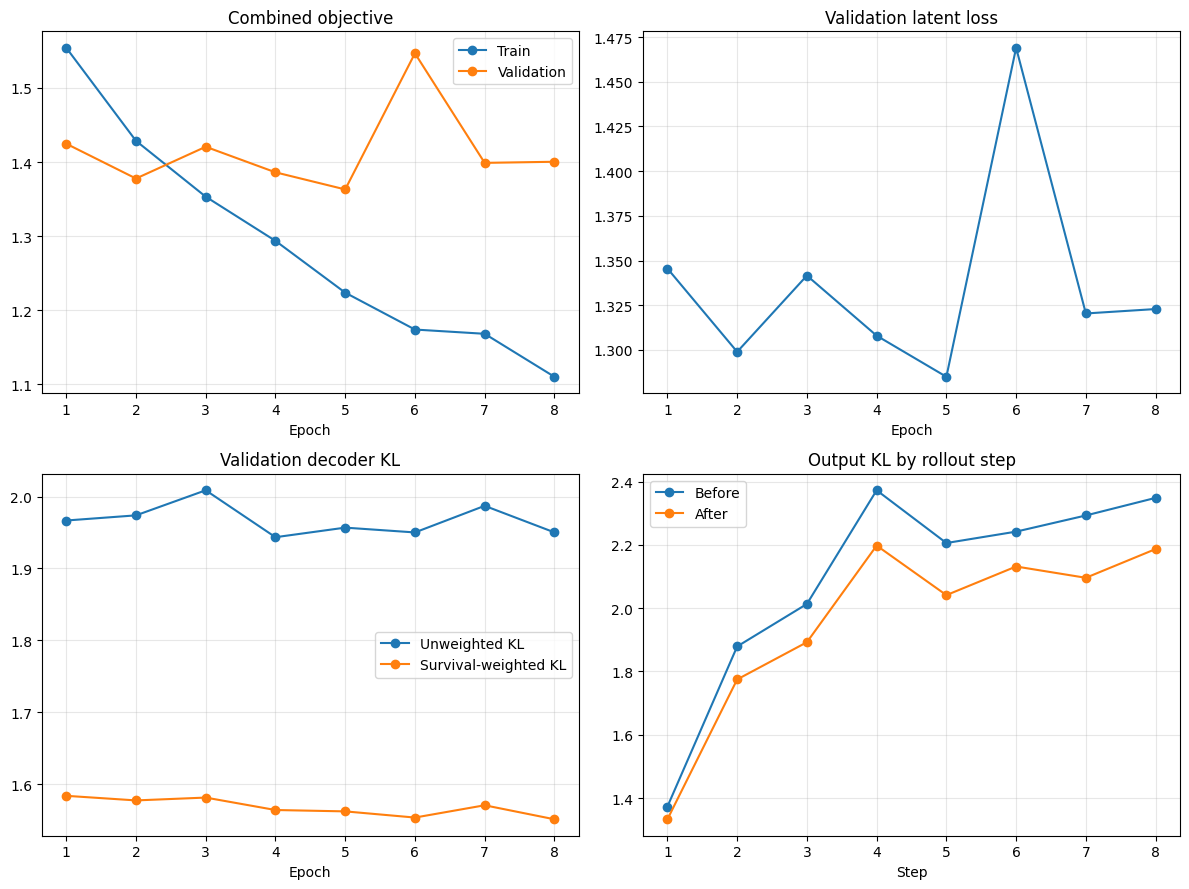

Saved figure to:
/content/drive/MyDrive/ma2288_nextlat/results_v2/figures/17_survival_weighted_training.png


In [24]:
history_df = pd.DataFrame(training_history)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9),
)

axes[0, 0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train",
)

axes[0, 0].plot(
    history_df["epoch"],
    history_df["validation_loss"],
    marker="o",
    label="Validation",
)

axes[0, 0].set_title("Combined objective")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(
    history_df["epoch"],
    history_df["validation_latent_loss"],
    marker="o",
)

axes[0, 1].set_title("Validation latent loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(
    history_df["epoch"],
    history_df[
        "validation_unweighted_output_kl"
    ],
    marker="o",
    label="Unweighted KL",
)

axes[1, 0].plot(
    history_df["epoch"],
    history_df[
        "validation_survival_weighted_output_kl"
    ],
    marker="o",
    label="Survival-weighted KL",
)

axes[1, 0].set_title("Validation decoder KL")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(
    step_comparison["step"],
    step_comparison["before_output_kl"],
    marker="o",
    label="Before",
)

axes[1, 1].plot(
    step_comparison["step"],
    step_comparison["after_output_kl"],
    marker="o",
    label="After",
)

axes[1, 1].set_title("Output KL by rollout step")
axes[1, 1].set_xlabel("Step")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()

figure_path = (
    OUTPUT_FIGURE_DIR
    / "17_survival_weighted_training.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved figure to:")
print(figure_path)

In [25]:
history_path = (
    OUTPUT_TABLE_DIR
    / "17_survival_weighted_training_history.csv"
)

step_comparison_path = (
    OUTPUT_TABLE_DIR
    / "17_survival_weighted_step_comparison.csv"
)

summary_path = (
    OUTPUT_TABLE_DIR
    / "17_survival_weighted_summary.json"
)

history_df.to_csv(
    history_path,
    index=False,
)

step_comparison.to_csv(
    step_comparison_path,
    index=False,
)

with open(summary_path, "w") as file:
    json.dump(summary, file, indent=2)

print("Saved:")
print(history_path)
print(step_comparison_path)
print(summary_path)

Saved:
/content/drive/MyDrive/ma2288_nextlat/results_v2/tables/17_survival_weighted_training_history.csv
/content/drive/MyDrive/ma2288_nextlat/results_v2/tables/17_survival_weighted_step_comparison.csv
/content/drive/MyDrive/ma2288_nextlat/results_v2/tables/17_survival_weighted_summary.json


In [26]:
checkpoint_to_save = {
    "model_state_dict":
        transition_model.state_dict(),

    "model_class":
        "ResidualLatentTransition",

    "hidden_size":
        hidden_size,

    "token_embedding_size":
        target_model.config.n_embd,

    "intermediate_size":
        512,

    "base_model_name":
        MODEL_NAME,

    "training_objective":
        "on_policy_survival_weighted_decoder_kl",

    "beta":
        BETA,

    "learning_rate":
        LEARNING_RATE,

    "best_epoch":
        best_epoch,

    "best_validation_loss":
        best_validation_loss,

    "baseline_metrics":
        baseline_metrics,

    "final_metrics":
        final_metrics,

    "summary":
        summary,

    "train_prompt_ids":
        train_prompt_ids,

    "validation_prompt_ids":
        validation_prompt_ids,

    "source_rollout_path":
        str(ONPOLICY_PATH),

    "base_checkpoint_path":
        str(BASE_CHECKPOINT_PATH),

    "seed":
        SEED,
}

torch.save(
    checkpoint_to_save,
    OUTPUT_CHECKPOINT_PATH,
)

print("Saved checkpoint:")
print(OUTPUT_CHECKPOINT_PATH)

print(
    "File size MB:",
    OUTPUT_CHECKPOINT_PATH.stat().st_size
    / (1024 ** 2),
)

Saved checkpoint:
/content/drive/MyDrive/ma2288_nextlat/checkpoints_v2/survival_weighted_transition_seed42.pt
File size MB: 4.525448799133301


In [27]:
reloaded_checkpoint = torch.load(
    OUTPUT_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

reloaded_model = ResidualLatentTransition(
    hidden_size=reloaded_checkpoint["hidden_size"],
    token_embedding_size=reloaded_checkpoint[
        "token_embedding_size"
    ],
    intermediate_size=reloaded_checkpoint[
        "intermediate_size"
    ],
)

reloaded_model.load_state_dict(
    reloaded_checkpoint["model_state_dict"],
    strict=True,
)

original_state = transition_model.state_dict()
reloaded_state = reloaded_model.state_dict()

maximum_parameter_difference = max(
    (
        original_state[key].detach().cpu()
        - reloaded_state[key]
    ).abs().max().item()
    for key in original_state
)

print(
    "Maximum parameter difference after reload:",
    maximum_parameter_difference,
)

assert maximum_parameter_difference == 0.0

print("Checkpoint reload verification passed.")

Maximum parameter difference after reload: 0.0
Checkpoint reload verification passed.
